# Linear Network Timescales

**Goal**: Compute and visualize effective timescales of a linear recurrent network for different coupling strengths $g$.

Connectivity matrix $W_{ij} \sim \mathcal{N}(0, 1/N)$. By the circular law, eigenvalues of $W$ are approximately uniform in the unit disk as $N \to \infty$.

The linearized dynamics are:
$$\tau \dot{x} = -x + gWx = (gW - I)x$$

The Jacobian is $M = \frac{1}{\tau}(gW - I)$, with eigenvalues:
$$\lambda_M = \frac{1}{\tau}(g \lambda_W - 1)$$

A mode is stable iff $\mathrm{Re}(\lambda_M) < 0$, i.e., $g \cdot \mathrm{Re}(\lambda_W) < 1$. The effective timescale of a stable mode is:
$$\tau_{\mathrm{eff}} = \frac{-1}{\mathrm{Re}(\lambda_M)} = \frac{\tau}{1 - g \cdot \mathrm{Re}(\lambda_W)}$$

As $g \to 1$ (edge of chaos), the slowest timescale diverges.

## Setup

In [68]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from typing import Tuple
from numpy.typing import NDArray

# Set random seed for reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print(f"Random seed: {SEED}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Random seed: 42


In [322]:
def generate_W(n_neurons: int, rng: np.random.Generator) -> NDArray:
    """
    Generate connectivity matrix with W_{ij} ~ N(0, 1/N).

    By the circular law, eigenvalues of W fill the unit disk as N -> inf.
    """
    return rng.standard_normal((n_neurons, n_neurons)) / np.sqrt(n_neurons)


def get_jacobian_eigenvalues(
    eigenvalues_W: NDArray,
    g: float,
    tau: float,
) -> NDArray:
    """
    Compute eigenvalues of Jacobian M = (1/tau)(g*W - I).

    lambda_M = (1/tau)(g * lambda_W - 1)
    """
    return (g * eigenvalues_W - 1.0) / tau


def get_effective_timescales(eigenvalues_M: NDArray) -> NDArray:
    """
    Get effective timescales from Jacobian eigenvalues.

    For stable modes (Re(lambda_M) < 0):
        tau_eff = -1 / Re(lambda_M)
    """
    real_parts = np.real(eigenvalues_M)
    stable_mask = real_parts < 0
    return -1.0 / real_parts[stable_mask]

def get_stable_indices(eigenvalues_M: NDArray) -> NDArray:
    """Return indices of stable modes (Re(λ_M) < 0)."""
    return np.where(np.real(eigenvalues_M) < 0)[0]


def get_real_eigenvalue_indices(eigenvalues_M: NDArray, tol: float = 1e-8) -> NDArray:
    """Return indices of real-eigenvalue stable modes (Re(λ_M) < 0, Im(λ_M) < tol)."""
    return np.where(np.abs(np.imag(eigenvalues_M)) < tol)[0]


def fit_powerlaw_slope(
    timescales: NDArray, n_bins: int = 50
) -> Tuple[float, float, NDArray, NDArray, float]:
    """
    Fit power-law slope to timescale distribution using log-log histogram.

    Returns: slope, intercept, bin_centers, hist_density, r_squared
    """
    log_tau = np.log10(timescales)
    bins = np.logspace(log_tau.min(), log_tau.max(), n_bins + 1)
    hist, bin_edges = np.histogram(timescales, bins=bins, density=True)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # geometric mean

    valid_mask = hist > 0
    slope, intercept, r_value, _, _ = stats.linregress(
        np.log10(bin_centers[valid_mask]),
        np.log10(hist[valid_mask]),
    )
    return slope, intercept, bin_centers, hist, r_value**2


# --- Identify conjugate pairs ---
# For each selected mode, find its conjugate partner (the index j where λ_j ≈ conj(λ_i))
def find_conjugate(idx, eigs, tol=1e-8):
    target = np.conj(eigs[idx])
    diffs  = np.abs(eigs - target)
    diffs[idx] = np.inf   # exclude self
    partner = np.argmin(diffs)
    return partner if diffs[partner] < tol else None


print("Helper functions defined.")

Helper functions defined.


## Configuration

In [100]:
config = {
    "n_neurons": 3000,
    "tau": 1.0,
    "g_values": [0.3, 0.6, 0.9, 0.99, 1.0, 1.2, 2],
    "n_bins": 50,
}

---
# Part 1: Random Matrix Eigenvalue Spectra and Timescale Distributions

1. Generate one $W$ matrix, $W_{ij} \sim \mathcal{N}(0, 1/N)$
2. Compute $M = \frac{1}{\tau}(gW - I)$ eigenvalues and effective timescales for several values of $g$.

### 1.1 Generate $W$ and Verify Circular Law

W shape: (3000, 3000)
W spectral radius: 1.0207  (expected ~1.0)


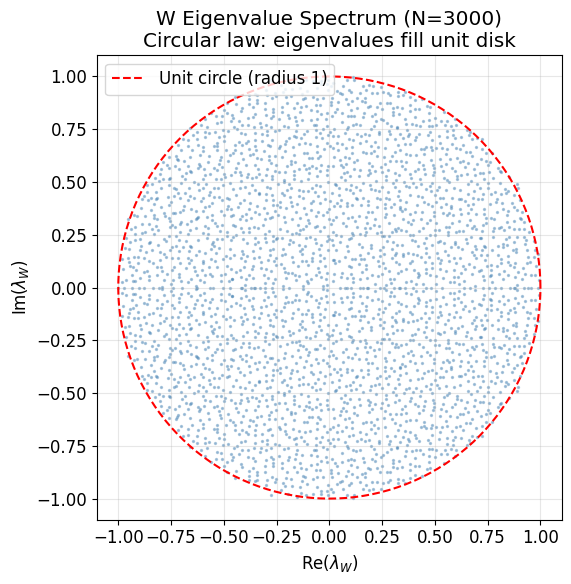

In [80]:
N = config["n_neurons"]
tau = config["tau"]
g_values = config["g_values"]

# Generate connectivity matrix W_{ij} ~ N(0, 1/N)
W = generate_W(N, rng)
eigenvalues_W = np.linalg.eigvals(W)

print(f"W shape: {W.shape}")
print(f"W spectral radius: {np.abs(eigenvalues_W).max():.4f}  (expected ~1.0)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.real(eigenvalues_W), np.imag(eigenvalues_W), s=2, alpha=0.4, color='steelblue')
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'r--', linewidth=1.5, label='Unit circle (radius 1)')
ax.set_xlabel(r'Re($\lambda_W$)')
ax.set_ylabel(r'Im($\lambda_W$)')
ax.set_title(f'W Eigenvalue Spectrum (N={N})\nCircular law: eigenvalues fill unit disk')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Jacobian Eigenspectra and Timescales for Multiple $g$ Values 

(Gaussian $W$ & Orthogonal $W$)

Orthogonal $W$: see (https://github.com/pytorch/pytorch/blob/v2.10.0/torch/nn/init.py#L631)

In [81]:
# Eigenvalues of orthogonal matrix (nn.init.orthogonal_(gain=1.0))
Z = rng.standard_normal((N, N))
Q, R = np.linalg.qr(Z)
Q *= np.sign(np.diag(R))   # sign correction for Haar-uniform distribution
W_orth = Q                  # orthogonal matrix, all singular values = 1

eigenvalues_W_orth = np.linalg.eigvals(W_orth)

Gaussian  g=0.3: 3000/3000 stable, tau_eff in [0.769, 1.424]
Gaussian  g=0.6: 3000/3000 stable, tau_eff in [0.625, 2.474]
Gaussian  g=0.9: 3000/3000 stable, tau_eff in [0.526, 9.415]
Gaussian  g=0.99: 3000/3000 stable, tau_eff in [0.502, 59.401]
Gaussian  g=1.0: 3000/3000 stable, tau_eff in [0.500, 144.847]
Gaussian  g=1.2: 2875/3000 stable, tau_eff in [0.454, 158.015]
Gaussian  g=2: 2416/3000 stable, tau_eff in [0.333, 385.630]
Orthogonal g=0.99: 3000/3000 stable, tau_eff in [0.503, 99.995]


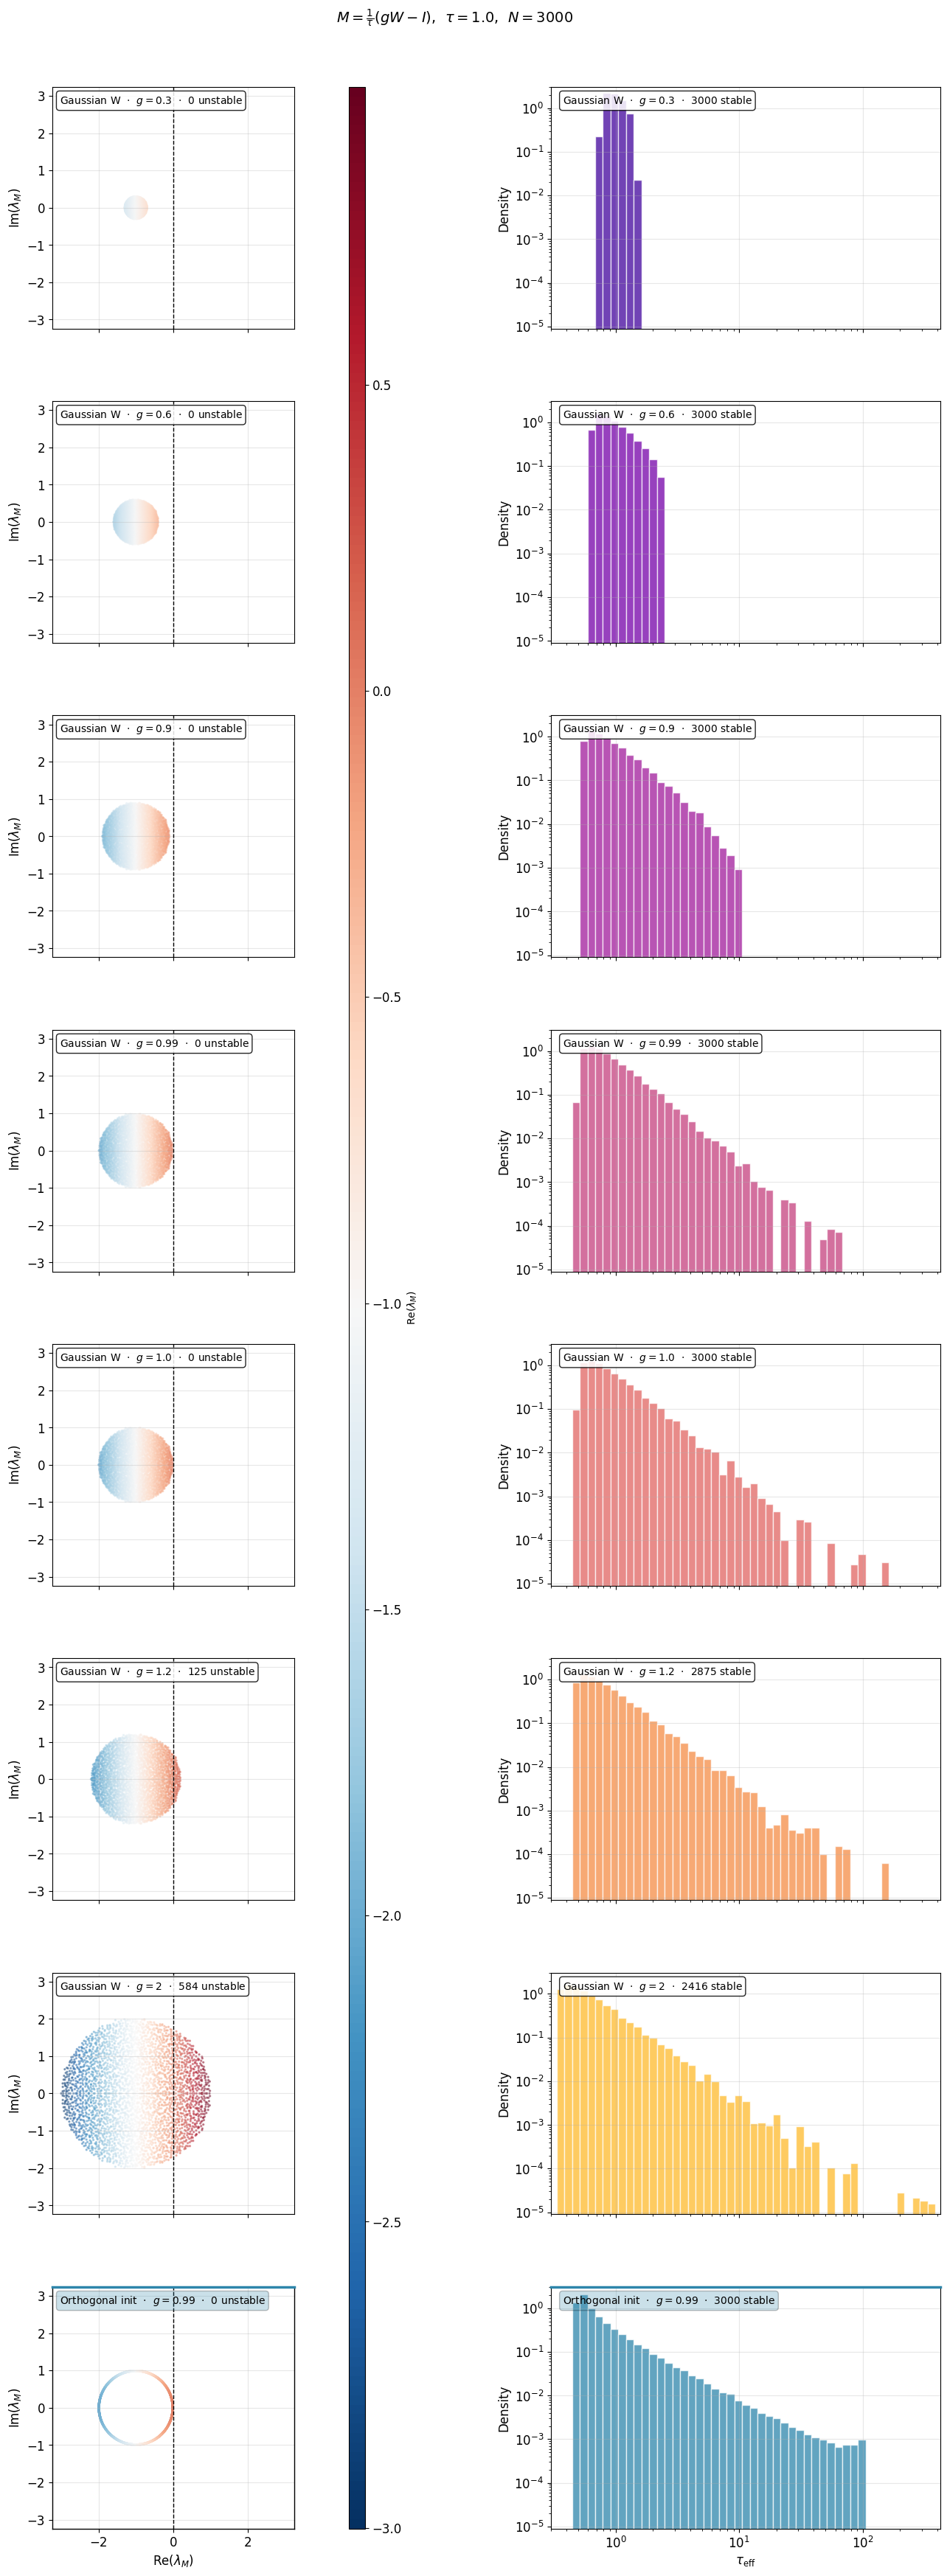

In [108]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

n_g = len(g_values)

g_orth = 0.99#max(g_values)   # match the top of the Gaussian sweep for a fair comparison
n_rows = n_g + 1         # one extra row for orthogonal

# --- Pass 1: Gaussian results ---
results = {}
for g in g_values:
    eigenvalues_M = get_jacobian_eigenvalues(eigenvalues_W, g, tau)
    timescales    = get_effective_timescales(eigenvalues_M)
    n_stable, n_unstable = len(timescales), N - len(timescales)
    results[g] = dict(eigenvalues_M=eigenvalues_M, timescales=timescales,
                      n_stable=n_stable, n_unstable=n_unstable)
    if n_stable > 0:
        print(f"Gaussian  g={g}: {n_stable}/{N} stable, "
              f"tau_eff in [{timescales.min():.3f}, {timescales.max():.3f}]")
    else:
        print(f"Gaussian  g={g}: 0/{N} stable")

# --- Orthogonal row ---
eigenvalues_M_orth = get_jacobian_eigenvalues(eigenvalues_W_orth, g_orth, tau)
timescales_orth    = get_effective_timescales(eigenvalues_M_orth)
n_stable_orth      = len(timescales_orth)
n_unstable_orth    = N - n_stable_orth
print(f"Orthogonal g={g_orth}: {n_stable_orth}/{N} stable, "
      f"tau_eff in [{timescales_orth.min():.3f}, {timescales_orth.max():.3f}]")

# --- Shared limits (include orthogonal in both) ---
all_eig = np.concatenate(
    [results[g]["eigenvalues_M"] for g in g_values] + [eigenvalues_M_orth]
)
xy_lim = max(np.abs(np.real(all_eig)).max(), np.abs(np.imag(all_eig)).max()) * 1.08
vmin_re, vmax_re = np.real(all_eig).min(), np.real(all_eig).max()

stable_ts_list = [results[g]["timescales"] for g in g_values
                  if len(results[g]["timescales"]) > 10]
if n_stable_orth > 10:
    stable_ts_list.append(timescales_orth)
if stable_ts_list:
    all_ts = np.concatenate(stable_ts_list)
    ts_xmin, ts_xmax = all_ts.min(), all_ts.max()
else:
    ts_xmin, ts_xmax = 0.1, 100.0

colors_gauss = plt.cm.plasma(np.linspace(0.1, 0.85, n_g))
color_orth   = "#2e86ab"   # distinct blue for orthogonal row

# --- Layout ---
fig = plt.figure(figsize=(14, 4.5 * n_rows))
outer = GridSpec(
    1, 2, figure=fig,
    width_ratios=[1, 1.1], wspace=0.5,
    left=0.07, right=0.97, top=0.95, bottom=0.03,
)
left_gs  = GridSpecFromSubplotSpec(n_rows, 2, subplot_spec=outer[0],
                                   width_ratios=[1, 0.05], wspace=0.08, hspace=0.3)
right_gs = GridSpecFromSubplotSpec(n_rows, 1, subplot_spec=outer[1], hspace=0.3)

axes_eig = [fig.add_subplot(left_gs[row, 0]) for row in range(n_rows)]
ax_cbar  = fig.add_subplot(left_gs[:, 1])
axes_ts  = [fig.add_subplot(right_gs[row])   for row in range(n_rows)]

# --- Gaussian rows ---
for row, (g, color) in enumerate(zip(g_values, colors_gauss)):
    eig_M      = results[g]["eigenvalues_M"]
    timescales = results[g]["timescales"]
    n_stable   = results[g]["n_stable"]
    n_unstable = results[g]["n_unstable"]

    ax = axes_eig[row]
    ax.scatter(np.real(eig_M), np.imag(eig_M), c=np.real(eig_M), cmap='RdBu_r',
               s=2, alpha=0.4, vmin=vmin_re, vmax=vmax_re, rasterized=True)
    ax.axvline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlim(-xy_lim, xy_lim)
    ax.set_ylim(-xy_lim, xy_lim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_ylabel(r'Im($\lambda_M$)')
    ax.annotate(f'Gaussian W  ·  $g = {g}$  ·  {n_unstable} unstable',
                xy=(0.03, 0.97), xycoords='axes fraction', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    ax.grid(True, alpha=0.3)
    ax.set_xticklabels([])

    ax = axes_ts[row]
    if n_stable > 10:
        bins = np.logspace(np.log10(ts_xmin), np.log10(ts_xmax), config["n_bins"])
        ax.hist(timescales, bins=bins, density=True, alpha=0.75,
                edgecolor='white', color=color)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(ts_xmin * 0.9, ts_xmax * 1.1)
    ax.set_ylabel('Density')
    ax.annotate(f'Gaussian W  ·  $g = {g}$  ·  {n_stable} stable',
                xy=(0.03, 0.97), xycoords='axes fraction', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    ax.grid(True, alpha=0.3)
    ax.set_xticklabels([])

# --- Orthogonal row (last) ---
orth_row = n_g

ax = axes_eig[orth_row]
ax.scatter(np.real(eigenvalues_M_orth), np.imag(eigenvalues_M_orth),
           c=np.real(eigenvalues_M_orth), cmap='RdBu_r', s=2, alpha=0.5,
           vmin=vmin_re, vmax=vmax_re, rasterized=True)
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlim(-xy_lim, xy_lim)
ax.set_ylim(-xy_lim, xy_lim)
ax.set_aspect('equal', adjustable='box')
ax.set_ylabel(r'Im($\lambda_M$)')
ax.set_xlabel(r'Re($\lambda_M$)')
ax.annotate(f'Orthogonal init  ·  $g = {g_orth}$  ·  {n_unstable_orth} unstable',
            xy=(0.03, 0.97), xycoords='axes fraction', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc=color_orth, alpha=0.25))
ax.grid(True, alpha=0.3)
# Thicker top spine to visually separate from Gaussian rows
for spine in ax.spines.values():
    spine.set_linewidth(1)
axes_eig[orth_row].spines['top'].set_linewidth(2.5)
axes_eig[orth_row].spines['top'].set_color(color_orth)

ax = axes_ts[orth_row]
if n_stable_orth > 10:
    bins = np.logspace(np.log10(ts_xmin), np.log10(ts_xmax), config["n_bins"])
    ax.hist(timescales_orth, bins=bins, density=True, alpha=0.75,
            edgecolor='white', color=color_orth)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(ts_xmin * 0.9, ts_xmax * 1.1)
ax.set_ylabel('Density')
ax.set_xlabel(r'$\tau_{\mathrm{eff}}$')
ax.annotate(f'Orthogonal init  ·  $g = {g_orth}$  ·  {n_stable_orth} stable',
            xy=(0.03, 0.97), xycoords='axes fraction', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc=color_orth, alpha=0.25))
ax.grid(True, alpha=0.3)
axes_ts[orth_row].spines['top'].set_linewidth(2.5)
axes_ts[orth_row].spines['top'].set_color(color_orth)

# Sync y-limits across timescale column
ylims = [ax.get_ylim() for ax in axes_ts]
for ax in axes_ts:
    ax.set_ylim(min(y[0] for y in ylims), max(y[1] for y in ylims))

# Colorbar
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin_re, vmax=vmax_re), cmap='RdBu_r')
cb = fig.colorbar(sm, cax=ax_cbar)
cb.set_label(r'Re($\lambda_M$)', fontsize=10)

fig.suptitle(
    rf'$M = \frac{{1}}{{\tau}}(gW - I)$,  $\tau={tau}$,  $N={N}$',
    fontsize=14,
)
plt.show()

### 1.3 Overlay Timescale Distributions and Power-Law Fits

/Users/facosta/Library/Caches/pypoetry/virtualenvs/timescales-cyRpnAeJ-py3.11/lib/python3.11/site-packages/powerlaw/fitting.py:528: UserWarning: No valid values for xmin found.
  warnings.warn('No valid values for xmin found.')
/Users/facosta/Library/Caches/pypoetry/virtualenvs/timescales-cyRpnAeJ-py3.11/lib/python3.11/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Users/facosta/Library/Caches/pypoetry/virtualenvs/timescales-cyRpnAeJ-py3.11/lib/python3.11/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


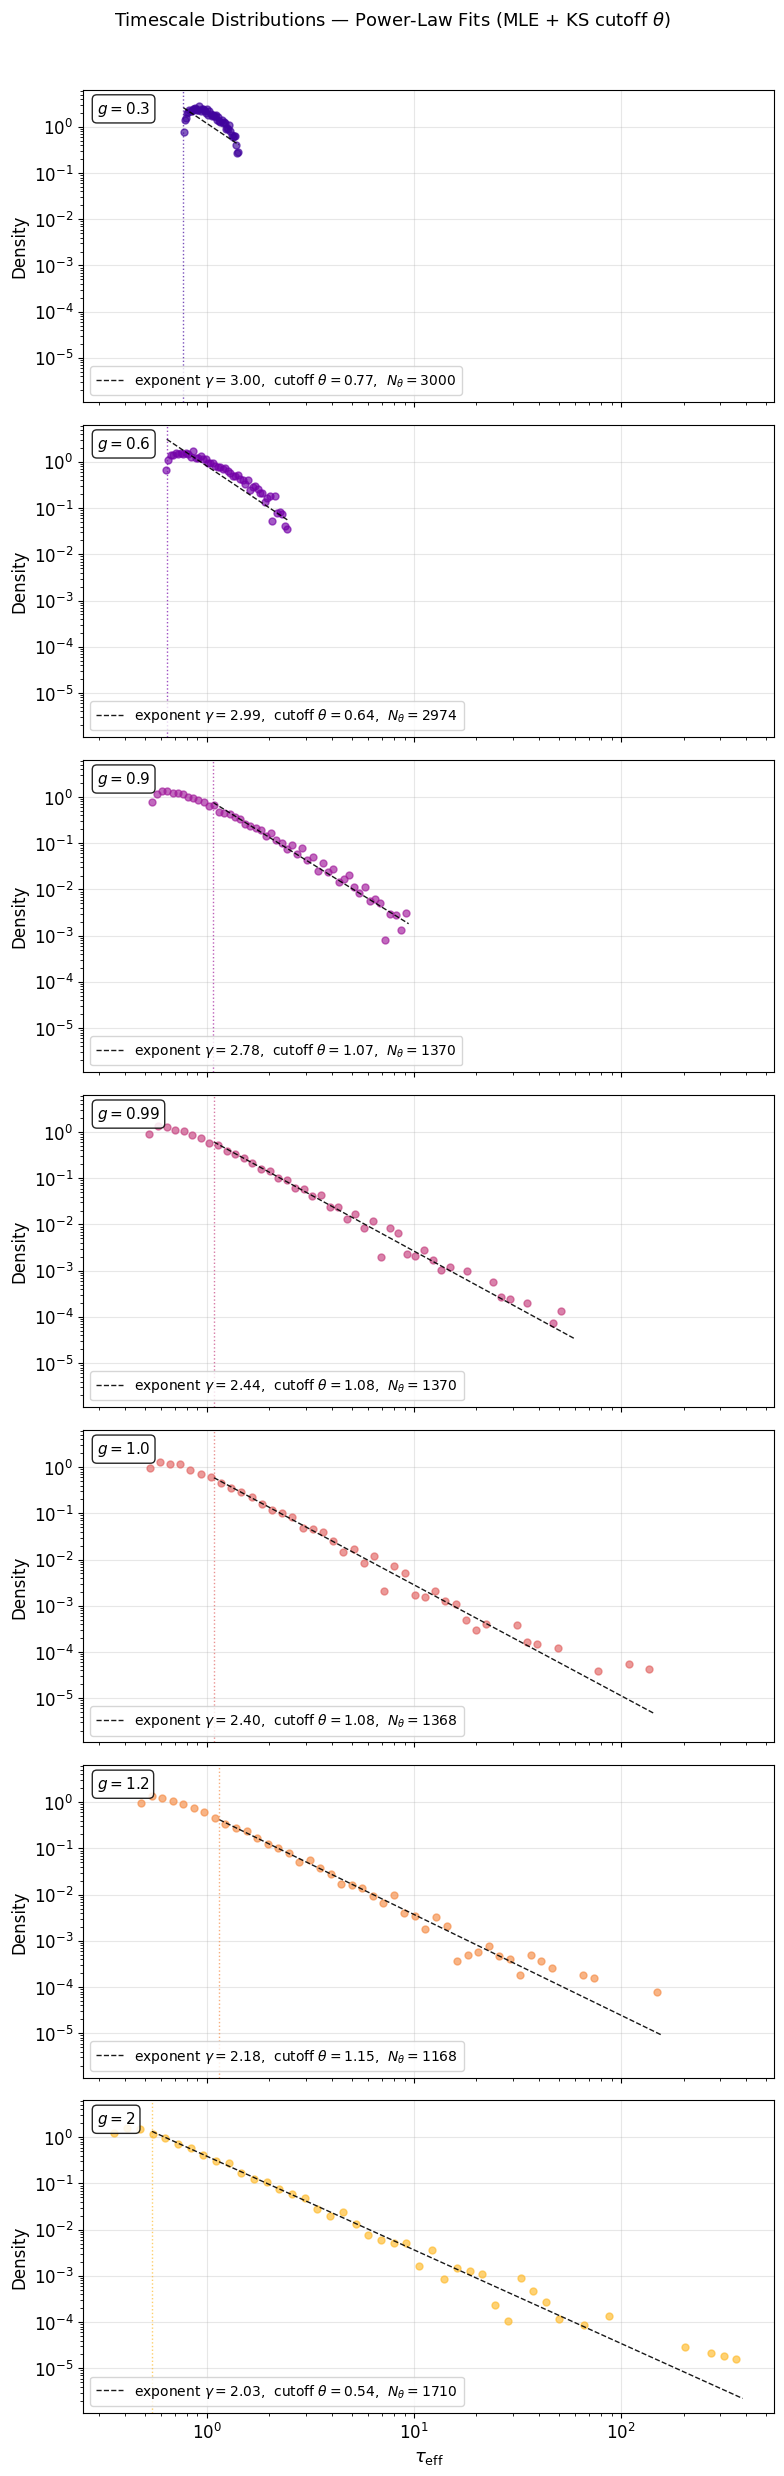

In [302]:
import powerlaw

fig, axes = plt.subplots(
    n_g, 1,
    figsize=(8, 3.5 * n_g),
    sharex=True, sharey=True,
)
colors = plt.cm.plasma(np.linspace(0.1, 0.85, n_g))

for ax, color, g in zip(axes, colors, g_values):
    timescales = results[g]["timescales"]

    if len(timescales) < 10:
        ax.annotate('insufficient stable modes', xy=(0.5, 0.5),
                    xycoords='axes fraction', ha='center', fontsize=11)
        continue

    # MLE fit with automatic KS-minimization
    fit     = powerlaw.Fit(timescales, xmax=None, discrete=False, verbose=False)
    gamma   = fit.alpha
    theta   = fit.xmin
    N_theta = (timescales >= theta).sum()

    # Empirical histogram
    log_tau = np.log10(timescales)
    bins = np.logspace(log_tau.min(), log_tau.max(), config["n_bins"] + 1)
    hist, bin_edges = np.histogram(timescales, bins=bins, density=True)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    valid = hist > 0
    ax.loglog(bin_centers[valid], hist[valid],
              'o', color=color, markersize=5, alpha=0.65)

    # Fitted power-law PDF above θ
    tau_tail = np.logspace(np.log10(theta), np.log10(timescales.max()), 200)
    f_tail = N_theta / len(timescales)
    ax.loglog(tau_tail, f_tail * fit.power_law.pdf(tau_tail),
              '--', color='black', linewidth=1, alpha=0.9,
              label=rf'exponent $\gamma = {gamma:.2f}$,  cutoff $\theta = {theta:.2f}$,  $N_\theta = {N_theta}$')

    # Cutoff marker
    ax.axvline(theta, color=color, linewidth=1, linestyle=':', alpha=0.7)

    ax.set_ylabel('Density')
    ax.legend(fontsize=10, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.annotate(f'$g = {g}$', xy=(0.02, 0.97), xycoords='axes fraction',
                va='top', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

axes[-1].set_xlabel(r'$\tau_{\mathrm{eff}}$', fontsize=13)

fig.suptitle(
    r'Timescale Distributions — Power-Law Fits (MLE + KS cutoff $\theta$)',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show();

### 1.4 Jacobian Eigenspectra and Timescales for Multiple scalar $\tau$ Values

tau=0.2: 3000/3000 stable, tau_eff in [0.105, 1.883]
tau=0.5: 3000/3000 stable, tau_eff in [0.263, 4.708]
tau=1.0: 3000/3000 stable, tau_eff in [0.526, 9.415]
tau=1.5: 3000/3000 stable, tau_eff in [0.789, 14.123]


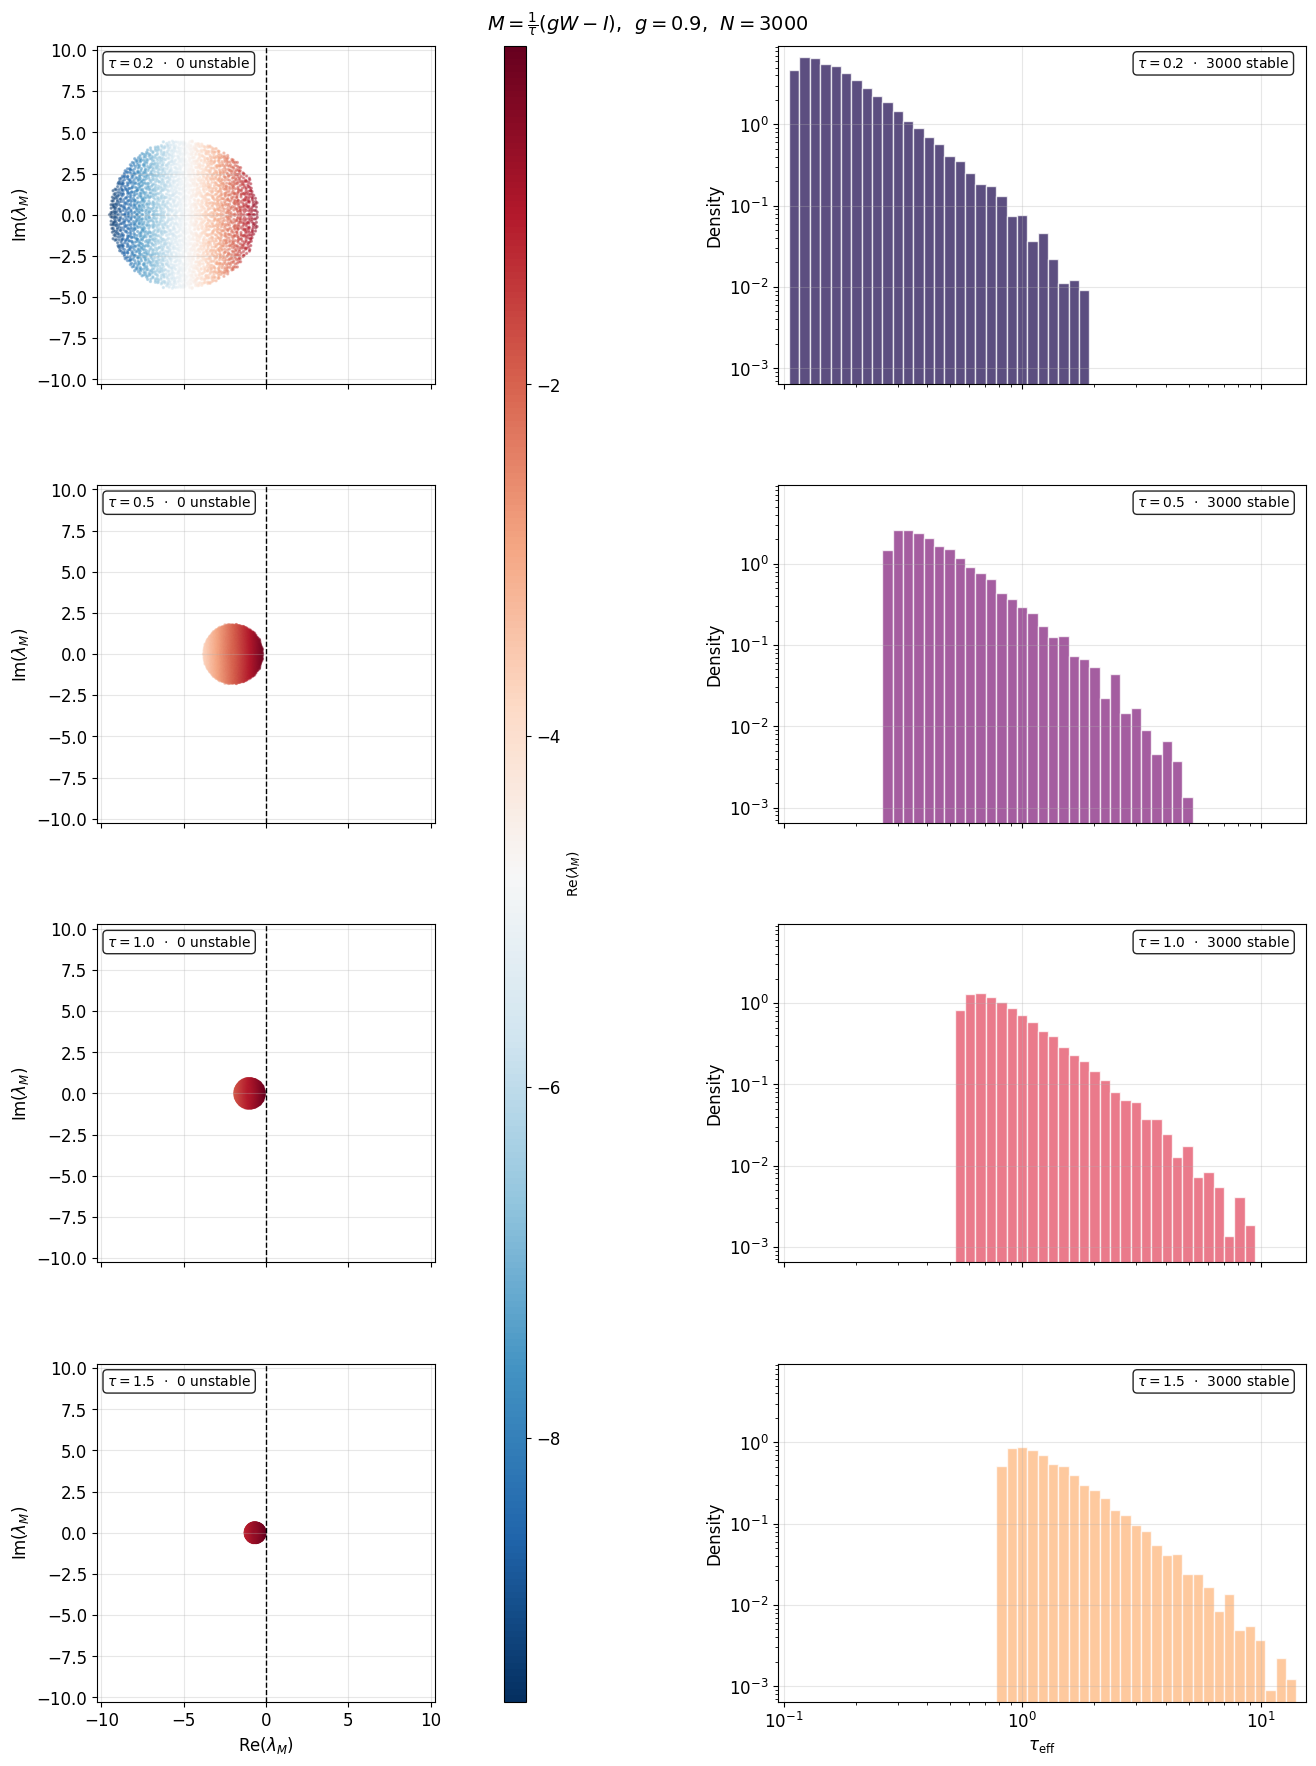

In [109]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

g_fixed   = 0.9   # fix coupling strength
tau_values = [0.2, 0.5, 1.0, 1.5]   # adjust to taste

n_tau = len(tau_values)

# --- Pass 1: compute all results ---
results_tau = {}
for tau_val in tau_values:
    eigenvalues_M = get_jacobian_eigenvalues(eigenvalues_W, g_fixed, tau_val)
    timescales    = get_effective_timescales(eigenvalues_M)
    n_stable      = len(timescales)
    n_unstable    = N - n_stable
    results_tau[tau_val] = {
        "eigenvalues_M": eigenvalues_M,
        "timescales":    timescales,
        "n_stable":      n_stable,
        "n_unstable":    n_unstable,
    }
    if n_stable > 0:
        print(f"tau={tau_val}: {n_stable}/{N} stable, "
              f"tau_eff in [{timescales.min():.3f}, {timescales.max():.3f}]")
    else:
        print(f"tau={tau_val}: 0/{N} stable")

# --- Shared limits ---
all_eig = np.concatenate([results_tau[t]["eigenvalues_M"] for t in tau_values])
xy_lim   = max(np.abs(np.real(all_eig)).max(), np.abs(np.imag(all_eig)).max()) * 1.08
vmin_re, vmax_re = np.real(all_eig).min(), np.real(all_eig).max()

stable_ts_list = [results_tau[t]["timescales"] for t in tau_values
                  if len(results_tau[t]["timescales"]) > 10]
if stable_ts_list:
    all_ts = np.concatenate(stable_ts_list)
    ts_xmin, ts_xmax = all_ts.min(), all_ts.max()
else:
    ts_xmin, ts_xmax = 0.1, 100.0

colors = plt.cm.magma(np.linspace(0.15, 0.85, n_tau))

# --- Layout (same structure as the g-sweep) ---
fig = plt.figure(figsize=(14, 4.5 * n_tau))
outer = GridSpec(
    1, 2, figure=fig,
    width_ratios=[1, 1.1], wspace=0.5,
    left=0.07, right=0.97, top=0.96, bottom=0.04,
)
left_gs = GridSpecFromSubplotSpec(
    n_tau, 2, subplot_spec=outer[0],
    width_ratios=[1, 0.05], wspace=0.08, hspace=0.3,
)
right_gs = GridSpecFromSubplotSpec(n_tau, 1, subplot_spec=outer[1], hspace=0.3)

axes_eig = [fig.add_subplot(left_gs[row, 0]) for row in range(n_tau)]
ax_cbar  = fig.add_subplot(left_gs[:, 1])
axes_ts  = [fig.add_subplot(right_gs[row])  for row in range(n_tau)]

# --- Draw ---
for row, (tau_val, color) in enumerate(zip(tau_values, colors)):
    eig_M      = results_tau[tau_val]["eigenvalues_M"]
    timescales = results_tau[tau_val]["timescales"]
    n_stable   = results_tau[tau_val]["n_stable"]
    n_unstable = results_tau[tau_val]["n_unstable"]

    # Left: eigenvalue spectrum
    ax = axes_eig[row]
    re_M, im_M = np.real(eig_M), np.imag(eig_M)
    ax.scatter(re_M, im_M, c=re_M, cmap='RdBu_r', s=2, alpha=0.4,
               vmin=vmin_re, vmax=vmax_re, rasterized=True)
    ax.axvline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlim(-xy_lim, xy_lim)
    ax.set_ylim(-xy_lim, xy_lim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_ylabel(r'Im($\lambda_M$)')
    ax.annotate(
        f'$\\tau = {tau_val}$  ·  {n_unstable} unstable',
        xy=(0.03, 0.97), xycoords='axes fraction', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85),
    )
    ax.grid(True, alpha=0.3)
    if row < n_tau - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel(r'Re($\lambda_M$)')

    # Right: timescale distribution
    ax = axes_ts[row]
    if n_stable > 10:
        bins = np.logspace(np.log10(ts_xmin), np.log10(ts_xmax), config["n_bins"])
        ax.hist(timescales, bins=bins, density=True, alpha=0.75,
                edgecolor='white', color=color)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(ts_xmin * 0.9, ts_xmax * 1.1)
    ax.set_ylabel('Density')
    ax.annotate(
        f'$\\tau = {tau_val}$  ·  {n_stable} stable',
        xy=(0.68, 0.97), xycoords='axes fraction', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85),
    )
    ax.grid(True, alpha=0.3)
    if row < n_tau - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel(r'$\tau_{\mathrm{eff}}$')

# Sync y-limits across timescale column
ylims = [ax.get_ylim() for ax in axes_ts]
for ax in axes_ts:
    ax.set_ylim(min(y[0] for y in ylims), max(y[1] for y in ylims))

# Colorbar
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin_re, vmax=vmax_re), cmap='RdBu_r')
cb = fig.colorbar(sm, cax=ax_cbar)
cb.set_label(r'Re($\lambda_M$)', fontsize=10)

fig.suptitle(
    rf'$M = \frac{{1}}{{\tau}}(gW - I)$,  $g={g_fixed}$,  $N={N}$',
    fontsize=14,
)
plt.show()

### 1.5: TODO: Add powerlaw fit like in 1.3 for the varying tau distributions

### 1.6: Number of real vs complex eigenvalues in a random matrix as a function of matrix size

Source: (Edelman, et al. 1994) https://www.ams.org/journals/jams/1994-07-01/S0894-0347-1994-1231689-0/

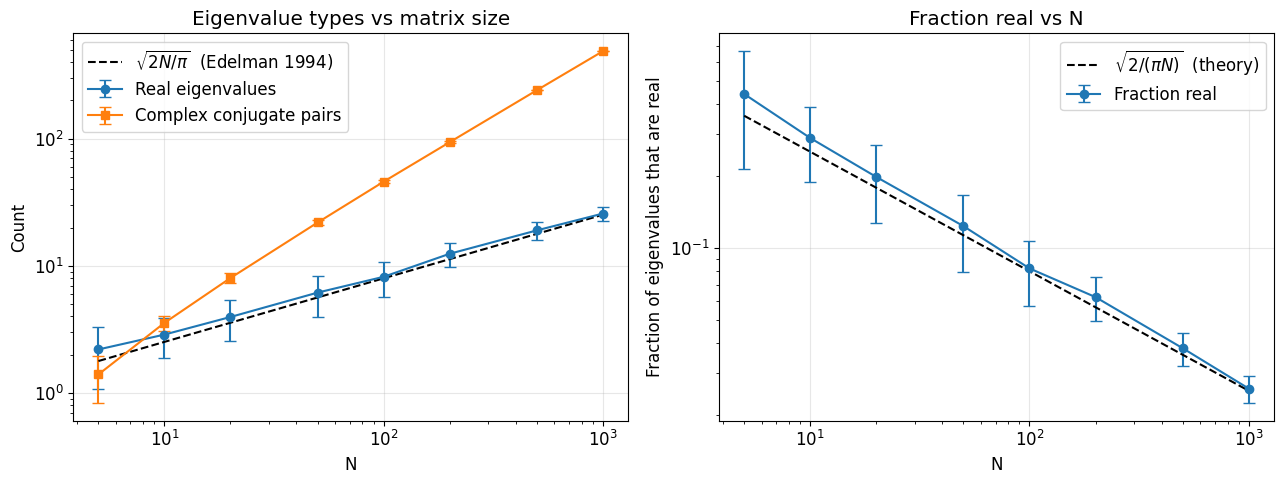

In [305]:
N_values = [5, 10, 20, 50, 100, 200, 500, 1000]
n_trials = 50     # realizations per N
tol      = 1e-10  # threshold for |Im(λ)| to call an eigenvalue "real"

n_real_mean,  n_real_std  = [], []
n_pairs_mean, n_pairs_std = [], []

for N in N_values:
    n_real_list, n_pairs_list = [], []
    for _ in range(n_trials):
        W    = rng.standard_normal((N, N)) / np.sqrt(N)
        eigs = np.linalg.eigvals(W)
        n_real  = int(np.sum(np.abs(np.imag(eigs)) < tol))
        n_pairs = (N - n_real) // 2
        n_real_list.append(n_real)
        n_pairs_list.append(n_pairs)
    n_real_mean.append(np.mean(n_real_list))
    n_real_std.append(np.std(n_real_list))
    n_pairs_mean.append(np.mean(n_pairs_list))
    n_pairs_std.append(np.std(n_pairs_list))

N_arr        = np.array(N_values)
n_real_mean  = np.array(n_real_mean)
n_real_std   = np.array(n_real_std)
n_pairs_mean = np.array(n_pairs_mean)
n_pairs_std  = np.array(n_pairs_std)

# Theoretical curve (Edelman 1994)
N_th         = np.logspace(np.log10(5), np.log10(1000), 200)
n_real_th    = np.sqrt(2 * N_th / np.pi)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute counts
ax = axes[0]
ax.errorbar(N_arr, n_real_mean,  yerr=n_real_std,  fmt='o-', capsize=4, label='Real eigenvalues')
ax.errorbar(N_arr, n_pairs_mean, yerr=n_pairs_std, fmt='s-', capsize=4, label='Complex conjugate pairs')
ax.plot(N_th, n_real_th, 'k--', linewidth=1.5, label=r'$\sqrt{2N/\pi}$  (Edelman 1994)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N')
ax.set_ylabel('Count')
ax.set_title('Eigenvalue types vs matrix size')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: fraction real
ax = axes[1]
ax.errorbar(N_arr, n_real_mean / N_arr, yerr=n_real_std / N_arr,
            fmt='o-', capsize=4, label='Fraction real')
ax.plot(N_th, np.sqrt(2 / (np.pi * N_th)), 'k--', linewidth=1.5,
        label=r'$\sqrt{2/(\pi N)}$  (theory)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N')
ax.set_ylabel('Fraction of eigenvalues that are real')
ax.set_title('Fraction real vs N')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 2: Simulation Validation

Verify that simulated autocorrelation timescales match eigenvalue predictions.

### 2.1 Weight Matrix and Eigendecomposition

In [310]:
# Simulation config
sim_config = {
    "n_neurons": 1000,
    "g": 0.99,
    "tau": 1.0,
    "dt": 0.1, # simulation time step
    "duration": 5000.0, # simulation duration
    "noise_std": 0.1, # no noise
}

In [319]:
n_neurons = sim_config["n_neurons"]
g_sim = sim_config["g"]
tau_sim = sim_config["tau"]

# Generate connectivity matrix W_{ij} ~ N(0, 1/N)
W_sim = generate_W(n_neurons, rng)

# Full eigendecomposition (needed for projections later)
eigenvalues_W_sim, eigenvectors_sim = np.linalg.eig(W_sim)

# Jacobian eigenvalues and theoretical timescales
eigenvalues_M_sim = get_jacobian_eigenvalues(eigenvalues_W_sim, g_sim, tau_sim)
tau_theory = get_effective_timescales(eigenvalues_M_sim)

real_eigenvalue_indices = get_real_eigenvalue_indices(eigenvalues_M_sim)


print(f"W shape: {W_sim.shape}")
print(f"g = {g_sim},  tau = {tau_sim}")
print(f"Stable modes: {len(tau_theory)}/{n_neurons}")
print(f"Real-eigenvalue modes: {len(real_eigenvalue_indices)}/{n_neurons}")
print(f"Theoretical timescale range: [{tau_theory.min():.3f}, {tau_theory.max():.3f}]")

W shape: (1000, 1000)
g = 0.99,  tau = 1.0
Stable modes: 1000/1000
Real-eigenvalue modes: 26/1000
Theoretical timescale range: [0.509, 758.166]


### 2.3 Simulate Linear ODE

$$\tau \dot{x} = -x + gWx + \eta(t)$$

Euler-Maruyama discretization:
$$x(t+dt) = x(t) + \frac{dt}{\tau}(-x + gWx) + \sqrt{\frac{dt}{\tau}} \sigma \eta$$

In [312]:
def simulate_linear_ode(
    W: NDArray,
    g: float,
    tau: float,
    dt: float,
    duration: float,
    noise_std: float,
    rng: np.random.Generator,
) -> NDArray:
    """
    Simulate tau*dx/dt = -x + g*W*x + noise using Euler-Maruyama.
    """
    n = W.shape[0]
    n_steps = int(duration / dt)

    activity = np.zeros((n_steps, n))
    x = rng.standard_normal(n) * 0.1

    dt_tau = dt / tau
    sqrt_dt_tau = np.sqrt(dt_tau)
    gW = g * W

    for t in range(n_steps):
        activity[t] = x
        noise = rng.standard_normal(n) * noise_std * sqrt_dt_tau
        x = x + dt_tau * (-x + gW @ x) + noise

        if t % 10000 == 0 and t > 0:
            print(f"  Step {t}/{n_steps}")

    return activity


print("Running simulation...")
activity = simulate_linear_ode(
    W_sim, g_sim, tau_sim,
    sim_config["dt"],
    sim_config["duration"],
    sim_config["noise_std"],
    rng,
)
print(f"Done. Activity shape: {activity.shape}")
print(f"Activity range: [{activity.min():.3f}, {activity.max():.3f}]")

Running simulation...
  Step 10000/50000
  Step 20000/50000
  Step 30000/50000
  Step 40000/50000
Done. Activity shape: (50000, 1000)
Activity range: [-1.532, 1.485]


In [313]:
# Discard initial transient for analysis
discard_steps = int(100 / sim_config["dt"])
activity_steady = activity[discard_steps:]

### 2.5 Autocorrelation Functions

In [325]:
def compute_autocorrelation(
    z_k: NDArray, 
    max_lag: int,
):
    """
    Autocorrelation for a mode projection, handling complex eigenvectors correctly.

    Real mode:    standard ACF of Re(z_k)     → pure exponential decay
    Complex mode: |E[z_k(t+τ) z_k*(t)]| / C(0) → exp(Re(λ)τ), oscillation-free
    
    Returns (acf, is_complex).
    """
    n = len(z_k)
    is_cx = np.iscomplexobj(z_k) and np.abs(np.imag(z_k)).max() > 1e-10
    z_centered = z_k - np.mean(z_k)
    fft_len = 2 ** int(np.ceil(np.log2(2 * n - 1)))
    Z = np.fft.fft(z_centered, fft_len)
    acf_full = np.fft.ifft(Z * np.conj(Z))          # E[z(t+τ) z*(t)]
    acf = np.abs(acf_full[:max_lag + 1]) if is_cx \
          else np.real(acf_full[:max_lag + 1])
    if acf[0] > 0:
        acf = acf / acf[0]
    return acf, is_cx


def fit_exponential_timescale(
    autocorr: NDArray,
    dt: float,
    fit_range: Tuple[int, int] = (1, None),
) -> float:
    """Fit exponential decay to autocorrelation; return timescale."""
    start, end = fit_range[0], fit_range[1] or len(autocorr)
    lags = np.arange(start, end)
    ac = autocorr[start:end]

    positive_mask = ac > 0.01
    if positive_mask.sum() < 5:
        return np.nan

    slope, *_ = stats.linregress(lags[positive_mask] * dt, np.log(ac[positive_mask]))
    return np.nan if slope >= 0 else -1.0 / slope

### 2.6 Compute Eigenvector projections

Individual neurons receive input from all eigenmodes; their autocorrelation is a sum of exponentials. Projecting onto eigenvectors isolates each mode → single exponential decay.

In [280]:
def project_onto_eigenvectors(activity: NDArray, eigenvectors: NDArray) -> NDArray:
    """Project neural activity onto left eigenvectors of W."""

    V_inv = np.linalg.inv(eigenvectors)
    return activity @ V_inv.T


print("Projecting neural activity onto eigenvectors of W. Note: eigenvectors of W are the same as eigenvectors of M")
projections = project_onto_eigenvectors(activity_steady, eigenvectors_sim)
print(f"Projections shape: {projections.shape}")

Projecting neural activity onto eigenvectors of W. Note: eigenvectors of W are the same as eigenvectors of M
Projections shape: (49000, 1000)


### 2.7 Compute autocorrelation and fit exponential for neurons and eigenmodes

In [326]:
max_lag = 100
dt      = sim_config["dt"]
g_sim   = sim_config["g"]
tau_sim = sim_config["tau"]

stable_indices  = get_stable_indices(eigenvalues_M_sim)
tau_theory_all  = get_effective_timescales(eigenvalues_M_sim)  # one per stable mode

# Fit all neuron autocorrelations
print("Fitting neuron timescales ...")
tau_neuron_fitted = np.full(n_neurons, np.nan)
for i in range(n_neurons):
    acf, _ = compute_autocorrelation(activity_steady[:, i], max_lag)
    tau_neuron_fitted[i] = fit_exponential_timescale(acf, dt)

# Fit all eigenmode autocorrelations (stable modes only)
print("Fitting eigenmode timescales ...")
tau_mode_fitted = np.full(len(stable_indices), np.nan)
for j, mode_idx in enumerate(stable_indices):
    acf, _ = compute_autocorrelation(projections[:, mode_idx], max_lag)
    tau_mode_fitted[j] = fit_exponential_timescale(acf, dt)

valid_neuron = np.isfinite(tau_neuron_fitted) & (tau_neuron_fitted > 0)
valid_mode   = np.isfinite(tau_mode_fitted)   & (tau_mode_fitted   > 0)
print(f"Valid neuron fits:    {valid_neuron.sum()}/{n_neurons}")
print(f"Valid eigenmode fits: {valid_mode.sum()}/{len(stable_indices)}")

Fitting neuron timescales ...
Fitting eigenmode timescales ...
Valid neuron fits:    1000/1000
Valid eigenmode fits: 1000/1000


### 2.8 Visualize neuron activity and eigenmode projections

#### Plotting setup

In [332]:
# --- Display subsets for Figures 1 & 2 ---
n_show = 10
rng_display = np.random.default_rng(0)

neuron_display_idx     = rng_display.choice(np.where(valid_neuron)[0], size=n_show, replace=False)
valid_mode_local       = np.where(valid_mode)[0]
mode_display_local_idx  = rng_display.choice(valid_mode_local, size=n_show, replace=False)
mode_display_global_idx = stable_indices[mode_display_local_idx]

_title_suffix = rf'$g={g_sim}$,  $\tau_0={tau_sim}$,  $N={n_neurons}$'

#### 2.8.1: Visualize traces

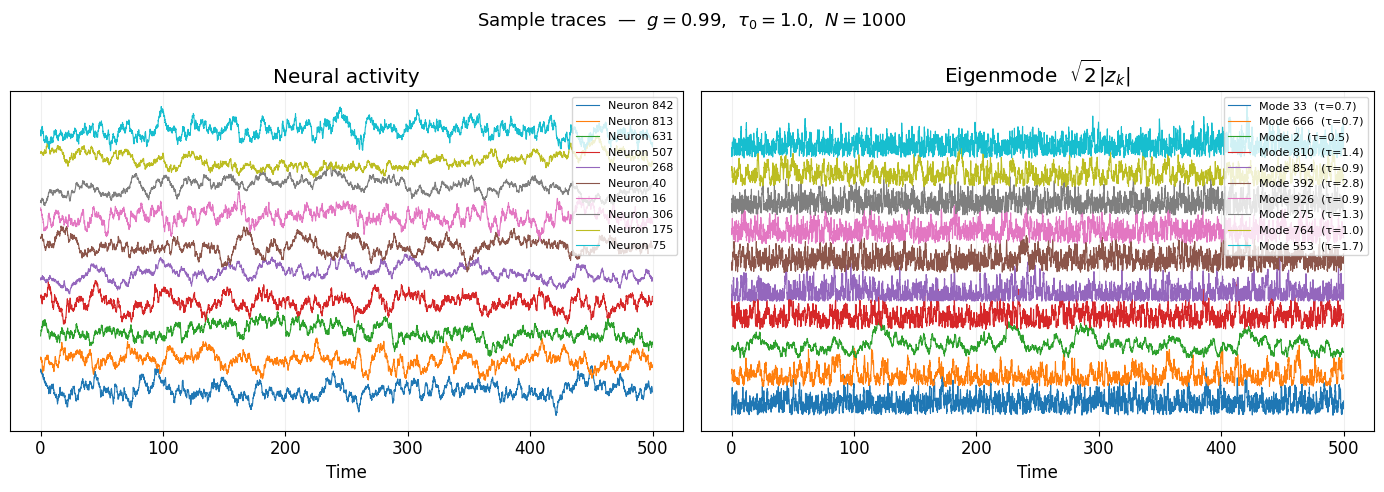

In [331]:
mode_trace = 'amplitude'   # 'real' or 'amplitude'

plot_steps = min(int(500 / dt), activity_steady.shape[0])
time_win   = np.arange(plot_steps) * dt
colors_show = plt.cm.tab10(np.arange(n_show) / 10)
offset_scale = 4.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: neurons
ax = axes[0]
for i in range(n_show):
    trace = activity_steady[:plot_steps, neuron_display_idx[i]]
    trace_norm = trace / (trace.std() + 1e-10)
    ax.plot(time_win, trace_norm + i * offset_scale,
            color=colors_show[i], linewidth=0.8,
            label=f'Neuron {neuron_display_idx[i]}')
ax.set_xlabel('Time')
ax.set_yticks([])
ax.set_title('Neural activity')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.2)

# Right panel: eigenmode traces
ax = axes[1]
for i in range(n_show):
    gidx   = mode_display_global_idx[i]
    lidx   = mode_display_local_idx[i]
    tau_th = tau_theory_all[lidx]
    eig_val = eigs[gidx]
    is_cx   = np.abs(np.imag(eig_val)) > 1e-8

    if mode_trace == 'amplitude':
        if is_cx:
            trace = np.sqrt(2) * np.abs(projections[:plot_steps, gidx])
        else:
            trace = np.abs(np.real(projections[:plot_steps, gidx]))
        label = f'Mode {gidx}  (τ={tau_th:.1f})'
    else:   # 'real'
        trace = np.real(projections[:plot_steps, gidx])
        suffix = 'ℝ' if not is_cx else 'ℂ'
        label = f'[{suffix}] Mode {gidx}  (τ={tau_th:.1f})'

    trace_norm = trace / (trace.std() + 1e-10)
    ax.plot(time_win, trace_norm + i * offset_scale,
            color=colors_show[i], linewidth=0.8, label=label)

right_title = r'Eigenmode  $\sqrt{2}|z_k|$' if mode_trace == 'amplitude' \
              else r'Eigenmode  $\mathrm{Re}(z_k)$'
ax.set_xlabel('Time')
ax.set_yticks([])
ax.set_title(right_title)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.2)

fig.suptitle(f'Sample traces  —  {_title_suffix}', fontsize=13)
plt.tight_layout()
plt.show()

#### 2.8.2: Visualize heatmaps

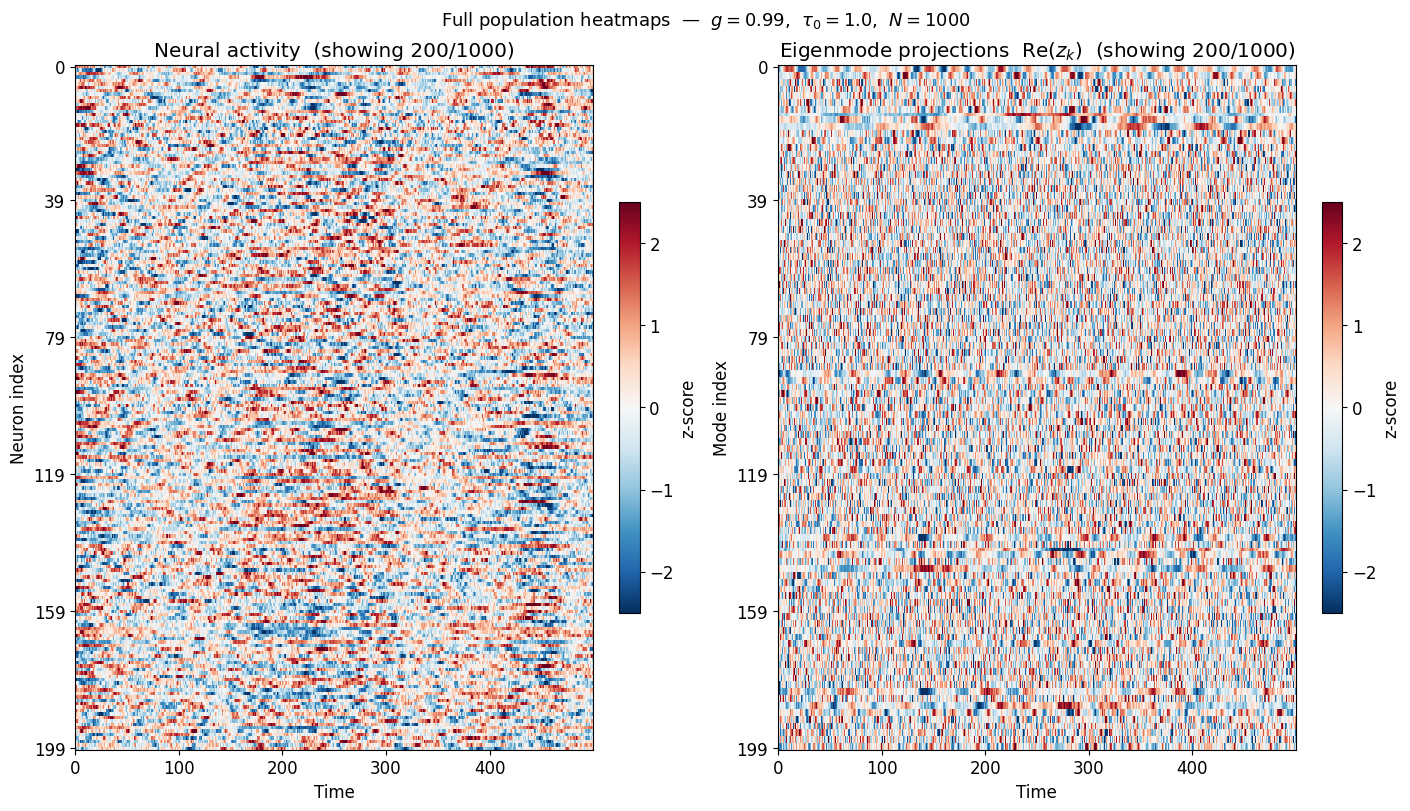

In [328]:
# --- Options ---
mode_display  = 'real' #'amplitude'      # 'real' or 'amplitude'
normalize     = True       # True = z-score per row, False = raw values
n_rows_show   = 200      # None = all rows, or an int e.g. 100

# --- Setup ---
plot_steps = min(int(500 / dt), activity_steady.shape[0])
time_win   = np.arange(plot_steps) * dt

def zscore_rows(arr):
    return (arr - arr.mean(axis=1, keepdims=True)) / (arr.std(axis=1, keepdims=True) + 1e-10)

row_idx = np.arange(n_rows_show if n_rows_show is not None else n_neurons)
N_rows  = len(row_idx)

# Neural activity: rows = selected neurons
raw_neurons = activity_steady[:plot_steps, row_idx].T          # (N_rows, plot_steps)

# Eigenmode projections: rows = selected mode indices
if mode_display == 'amplitude':
    raw_modes = np.abs(projections[:plot_steps, row_idx]).T    # always >= 0
    mode_label = r'$|z_k|$'
else:
    raw_modes = np.real(projections[:plot_steps, row_idx]).T   # oscillates around 0
    mode_label = r'$\mathrm{Re}(z_k)$'

data_neurons = zscore_rows(raw_neurons) if normalize else raw_neurons
data_modes   = zscore_rows(raw_modes)   if normalize else raw_modes

cbar_label = 'z-score' if normalize else 'raw'

# Colormap: diverging for z-score or real, sequential for raw amplitude
if mode_display == 'amplitude' and not normalize:
    cmap_modes, vmin_modes, vmax_modes = 'magma', 0, np.percentile(raw_modes, 98)
else:
    cmap_modes = vmin_modes = vmax_modes = None   # use shared kw below

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)

# kw_shared = dict(aspect='auto', vmin=-2.5, vmax=2.5, cmap='RdBu_r',
#                  extent=[0, time_win[-1], N_rows - 0.5, -0.5],
#                  interpolation='none')

if normalize:
    vmin_shared, vmax_shared = -2.5, 2.5
else:
    abs_max = max(np.abs(data_neurons).max(), np.abs(raw_modes).max())
    vmin_shared, vmax_shared = -abs_max, abs_max

kw_shared = dict(aspect='auto', vmin=vmin_shared, vmax=vmax_shared, cmap='RdBu_r',
                 extent=[0, time_win[-1], N_rows - 0.5, -0.5],
                 interpolation='none')

ytick_pos = np.linspace(0, N_rows - 1, 6, dtype=int)
ytick_labels = [str(p) for p in ytick_pos]

ax = axes[0]
im = ax.imshow(data_neurons, **kw_shared)
ax.set_xlabel('Time')
ax.set_ylabel('Neuron index')
ax.set_title(f'Neural activity  (showing {N_rows}/{n_neurons})')
ax.set_yticks(ytick_pos);  ax.set_yticklabels(ytick_labels)
fig.colorbar(im, ax=ax, label=cbar_label, shrink=0.6)

ax = axes[1]
kw_modes = {**kw_shared}
if cmap_modes is not None:
    kw_modes.update(cmap=cmap_modes, vmin=vmin_modes, vmax=vmax_modes)
im = ax.imshow(data_modes, **kw_modes)
ax.set_xlabel('Time')
ax.set_ylabel('Mode index')
ax.set_title(f'Eigenmode projections  {mode_label}  (showing {N_rows}/{n_neurons})')
ax.set_yticks(ytick_pos);  ax.set_yticklabels(ytick_labels)
fig.colorbar(im, ax=ax, label=cbar_label, shrink=0.6)

fig.suptitle(f'Full population heatmaps  —  {_title_suffix}', fontsize=13)
plt.show()

### 2.9: Plot selected autocorrelations and fitted exponentials for neurons and eigenmodes

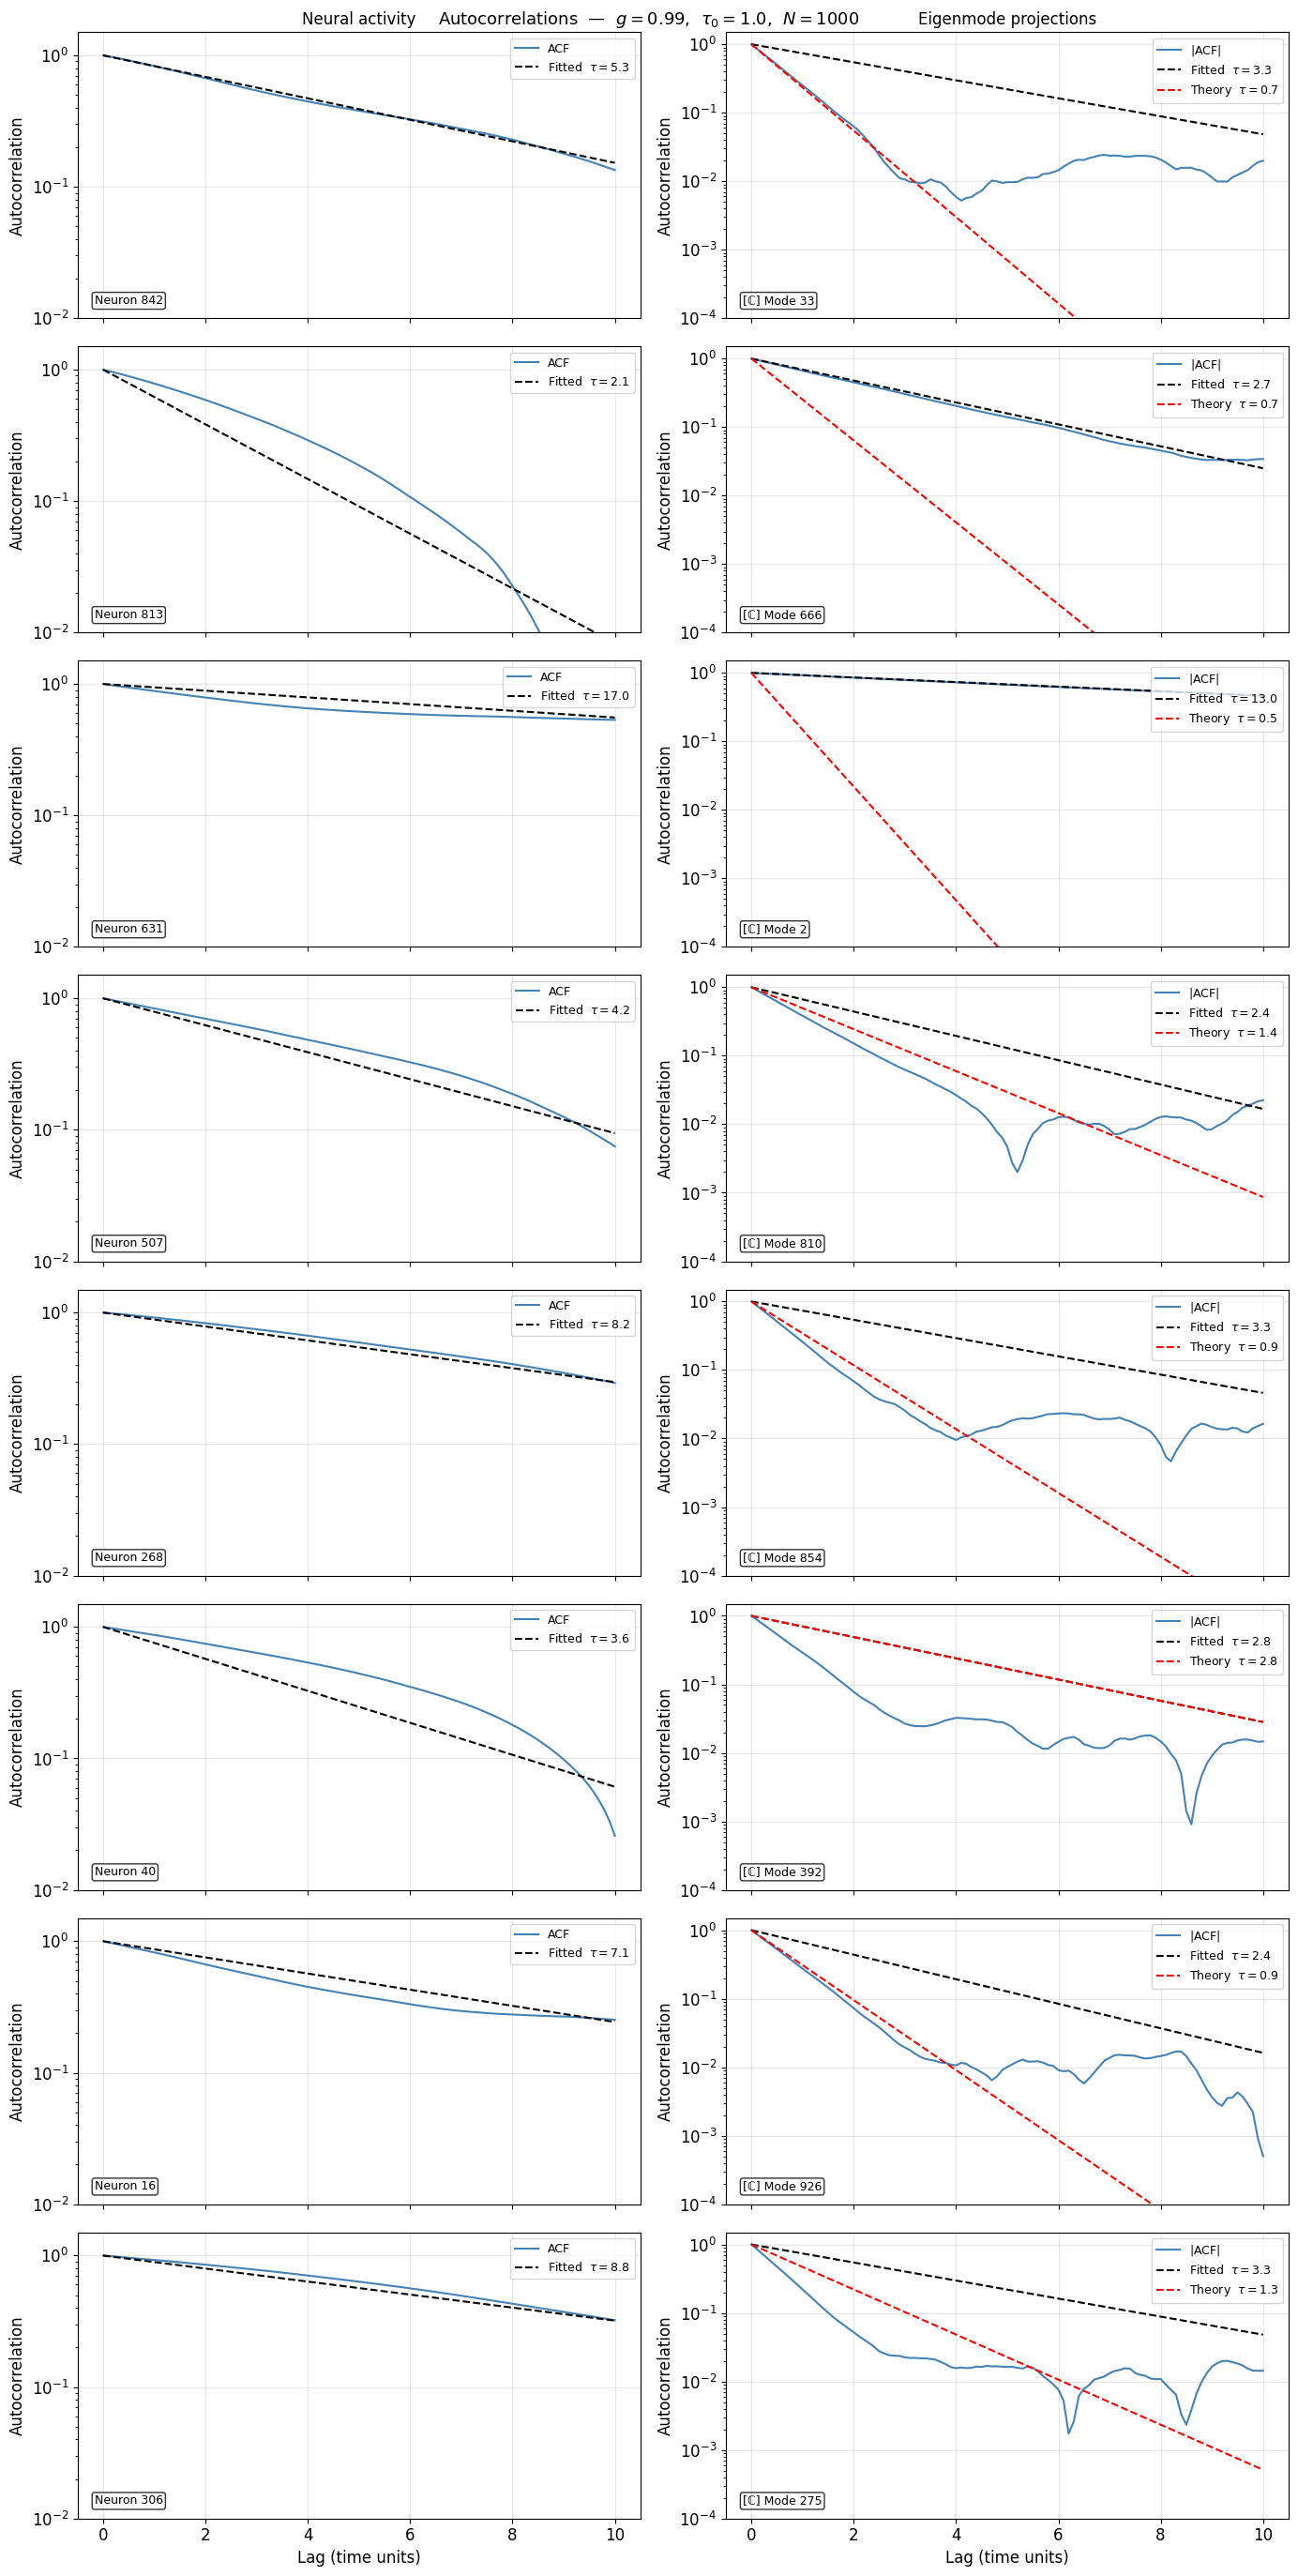

In [336]:
n_show_ac = 8
lags = np.arange(max_lag + 1) * dt

fig, axes = plt.subplots(n_show_ac, 2, figsize=(14, 3.5 * n_show_ac), sharex=True)
axes[0, 0].set_title('Neural activity', fontsize=12)
axes[0, 1].set_title('Eigenmode projections', fontsize=12)

for i in range(n_show_ac):
    # Left: neuron (real signal — existing approach unchanged)
    ax   = axes[i, 0]
    nidx = neuron_display_idx[i]
    acf, is_cx = compute_autocorrelation(activity_steady[:, nidx], max_lag)
    tau_fit = tau_neuron_fitted[nidx]

    ax.semilogy(lags, np.maximum(acf, 1e-6), color='steelblue', linewidth=1.5, label='ACF')
    if np.isfinite(tau_fit):
        ax.semilogy(lags, np.exp(-lags / tau_fit), 'k--', linewidth=1.5,
                    label=rf'Fitted  $\tau={tau_fit:.1f}$')
    ax.set_ylabel('Autocorrelation')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')
    ax.annotate(f'Neuron {nidx}', xy=(0.03, 0.05), xycoords='axes fraction',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.set_ylim([1e-2, 1.5])

    # Right: eigenmode (complex-aware ACF)
    ax   = axes[i, 1]
    lidx = mode_display_local_idx[i]
    gidx = mode_display_global_idx[i]

    acf, is_cx = compute_autocorrelation(projections[:, gidx], max_lag)
    tau_th  = tau_theory_all[lidx]
    tau_fit = tau_mode_fitted[lidx]

    ax.semilogy(lags, np.maximum(acf, 1e-6), color='steelblue', linewidth=1.5,
                label=r'$|\mathrm{ACF}|$' if is_cx else 'ACF')
    if np.isfinite(tau_fit):
        ax.semilogy(lags, np.exp(-lags / tau_fit), 'k--', linewidth=1.5,
                    label=rf'Fitted  $\tau={tau_fit:.1f}$')
    ax.semilogy(lags, np.exp(-lags / tau_th), 'r--', linewidth=1.5,
                label=rf'Theory  $\tau={tau_th:.1f}$')
    ax.set_ylabel('Autocorrelation')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')
    suffix = 'ℂ' if is_cx else 'ℝ'
    ax.annotate(f'[{suffix}] Mode {gidx}', xy=(0.03, 0.05), xycoords='axes fraction',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.set_ylim([1e-4, 1.5])

axes[-1, 0].set_xlabel('Lag (time units)')
axes[-1, 1].set_xlabel('Lag (time units)')
fig.suptitle(f'Autocorrelations  —  {_title_suffix}', fontsize=13)
plt.tight_layout()
plt.show()

### 2.10: Distributions of effective timescales: theory vs exponential fits (neurons, eigenmodes)

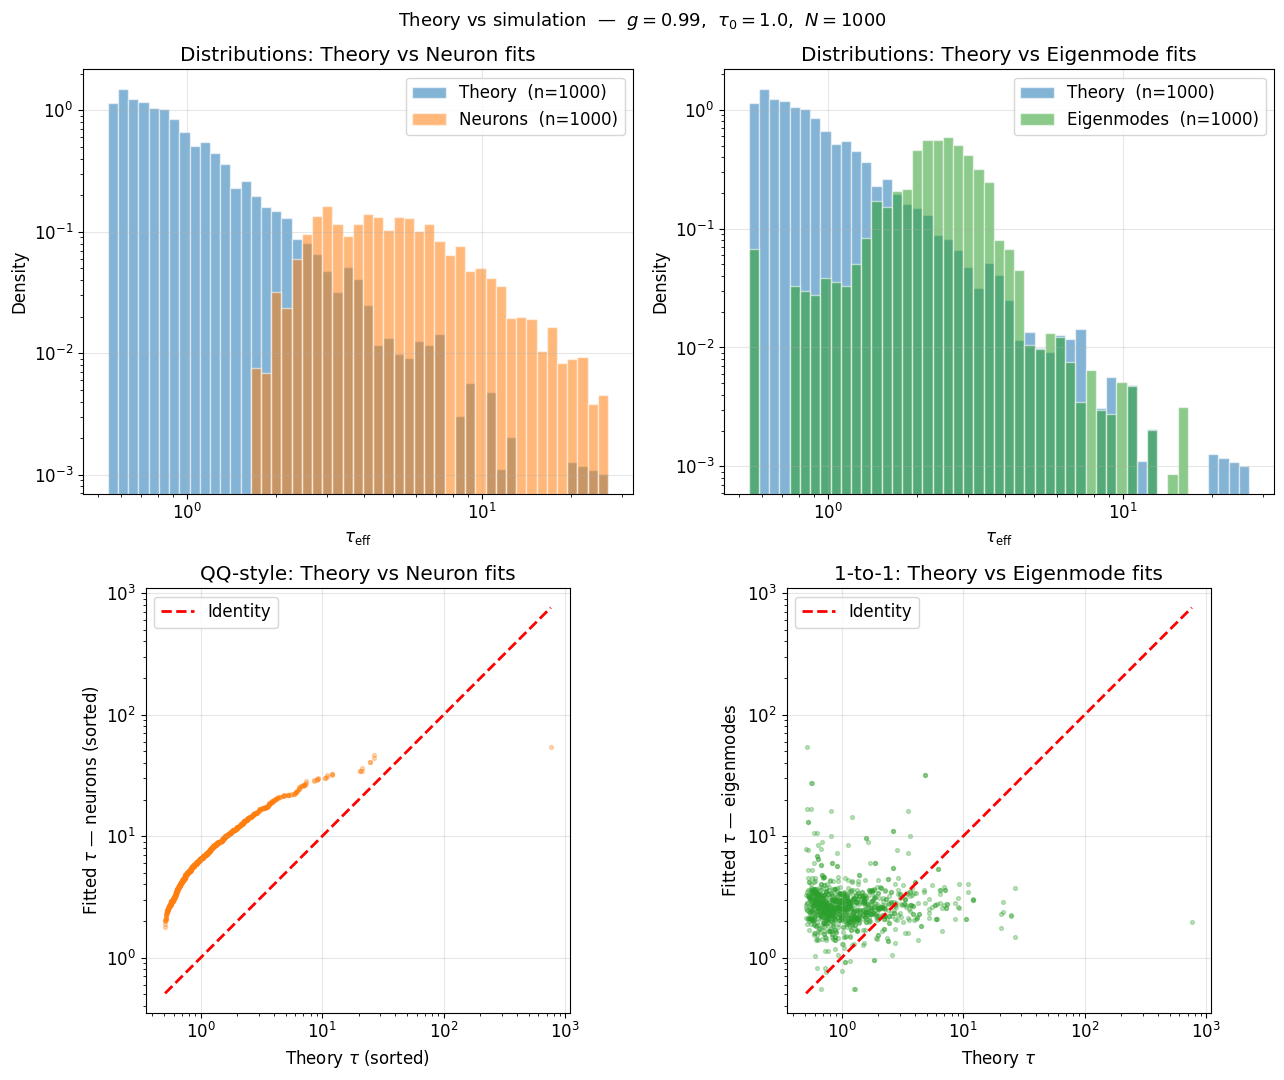

In [335]:
# Paired arrays for eigenmodes (1-to-1 with theory)
tau_theory_paired = tau_theory_all[valid_mode]
tau_mode_valid    = tau_mode_fitted[valid_mode]
tau_neuron_valid  = tau_neuron_fitted[valid_neuron]

# Shared histogram bins across all distributions
all_vals = np.concatenate([tau_theory_paired, tau_neuron_valid, tau_mode_valid])
bins = np.logspace(
    np.log10(np.percentile(all_vals, 1)),
    np.log10(np.percentile(all_vals, 99)),
    50,
)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# --- Top-left: histograms, theory vs neurons ---
ax = axes[0, 0]
ax.hist(tau_theory_paired, bins=bins, alpha=0.55, density=True, color='tab:blue', edgecolor='white',
        label=f'Theory  (n={len(tau_theory_paired)})')
ax.hist(tau_neuron_valid,  bins=bins, alpha=0.55, density=True, color='tab:orange', edgecolor='white',
        label=f'Neurons  (n={len(tau_neuron_valid)})')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\tau_{\rm eff}$'); ax.set_ylabel('Density')
ax.set_title('Distributions: Theory vs Neuron fits')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Top-right: histograms, theory vs eigenmodes ---
ax = axes[0, 1]
ax.hist(tau_theory_paired, bins=bins, alpha=0.55, density=True, color='tab:blue', edgecolor='white',
        label=f'Theory  (n={len(tau_theory_paired)})')
ax.hist(tau_mode_valid,    bins=bins, alpha=0.55, density=True, color='tab:green', edgecolor='white',
        label=f'Eigenmodes  (n={len(tau_mode_valid)})')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\tau_{\rm eff}$'); ax.set_ylabel('Density')
ax.set_title('Distributions: Theory vs Eigenmode fits')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Bottom-left: sorted QQ (no 1-to-1 mapping for neurons) ---
ax = axes[1, 0]
n_min = min(len(tau_theory_paired), len(tau_neuron_valid))
ax.scatter(np.sort(tau_theory_paired)[:n_min], np.sort(tau_neuron_valid)[:n_min],
           s=8, alpha=0.3, color='tab:orange')
vmin = min(tau_theory_paired.min(), tau_neuron_valid.min())
vmax = max(tau_theory_paired.max(), tau_neuron_valid.max())
ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2, label='Identity')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Theory $\tau$ (sorted)')
ax.set_ylabel(r'Fitted $\tau$ — neurons (sorted)')
ax.set_title('QQ-style: Theory vs Neuron fits')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

# --- Bottom-right: true 1-to-1 scatter for eigenmodes ---
ax = axes[1, 1]
ax.scatter(tau_theory_paired, tau_mode_valid, s=8, alpha=0.3, color='tab:green')
vmin = min(tau_theory_paired.min(), tau_mode_valid.min())
vmax = max(tau_theory_paired.max(), tau_mode_valid.max())
ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2, label='Identity')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Theory $\tau$')
ax.set_ylabel(r'Fitted $\tau$ — eigenmodes')
ax.set_title('1-to-1: Theory vs Eigenmode fits')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

fig.suptitle(f'Theory vs simulation  —  {_title_suffix}', fontsize=13)
plt.tight_layout()
plt.show()